<a href="https://colab.research.google.com/github/blackwithwhitegreen/ML-files/blob/main/toy_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Steps required

1. Preprocess + EDA(Exploratory Data Analysis) + Feature Selection.
2. Extract input and output cols
3. Train test split
4. Train the model
5. Evaluate the model/model selection
6. Deploy the model

In [ ]:
import numpy as pd
import pandas as pd

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/placement.csv')

In [ ]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.2 KB


#Preprocessing

In [ ]:
df = df.iloc[:,1:]

In [ ]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


#Exploratory Data Analysis(EDA)

In [ ]:
import matplotlib.pyplot as plt

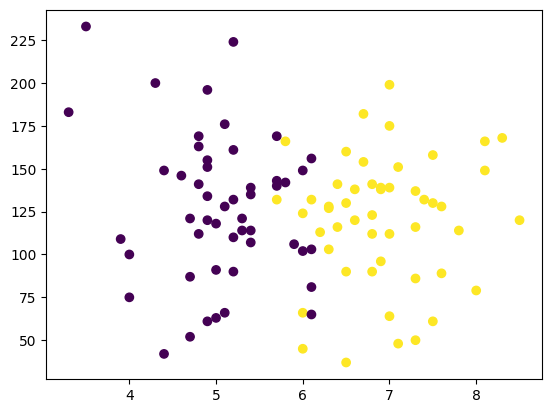

In [ ]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

#Extract input and output cols

In [ ]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [ ]:
y.shape

(100,)

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1)

In [ ]:
X_test

,cgpa,iq
28,5.2,90.0
90,7.3,86.0
88,4.4,149.0
36,5.7,140.0
85,5.8,166.0
7,5.0,63.0
52,7.0,175.0
19,5.2,132.0
93,6.8,112.0
86,5.1,128.0


In [ ]:
y_test

28    0
90    1
88    0
36    0
85    1
7     0
52    1
19    0
93    1
86    0
Name: placement, dtype: int64

#Scailing

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [ ]:
X_train = scaler.fit_transform(X_train)

In [ ]:
X_train

array([[-0.79365716,  1.30219434],
       [ 1.54119381, -0.23628638],
       [-0.53422927,  0.38406875],
       [-0.0153735 , -1.42736822],
       [-0.0153735 , -0.53405684],
       [ 0.07110246, -1.05515514],
       [-0.27480139,  1.12849491],
       [-1.05308505, -0.28591479],
       [-1.13956101, -1.77476709],
       [-0.7071812 ,  0.92998127],
       [-0.7071812 ,  2.49327619],
       [ 0.24405438,  0.08629829],
       [ 1.71414573, -1.10478356],
       [-0.79365716, -1.42736822],
       [ 1.80062169,  1.05405229],
       [-0.96660908,  0.25999773],
       [ 0.07110246,  0.80591024],
       [ 0.84938611,  1.87292106],
       [-0.96660908,  1.79847845],
       [-0.62070524, -0.23628638],
       [ 1.19528996,  0.21036932],
       [ 1.108814  ,  0.33444034],
       [ 1.108814  , -1.8243955 ],
       [ 1.80062169,  0.6322108 ],
       [-0.96660908,  0.68183921],
       [-0.0153735 , -1.94846653],
       [-0.96660908, -1.55143925],
       [-1.13956101, -0.90626991],
       [-1.22603697,

In [ ]:
X_test = scaler.transform(X_test)

In [ ]:

X_test

array([[-0.7071812 , -0.8318273 ],
       [ 1.108814  , -0.93108412],
       [-1.39898889,  0.6322108 ],
       [-0.27480139,  0.40888296],
       [-0.18832543,  1.05405229],
       [-0.88013312, -1.50181084],
       [ 0.84938611,  1.27738014],
       [-0.7071812 ,  0.21036932],
       [ 0.67643419, -0.28591479],
       [-0.79365716,  0.1111125 ]])

In [ ]:
from sklearn.linear_model import LogisticRegression


In [ ]:
clf = LogisticRegression()


In [ ]:
clf.fit(X_train,y_train)

LogisticRegression()

In [ ]:
y_pred = clf.predict(X_test)

In [ ]:
y_test

28    0
90    1
88    0
36    0
85    1
7     0
52    1
19    0
93    1
86    0
Name: placement, dtype: int64

In [ ]:
from sklearn.metrics import accuracy_score


In [ ]:
accuracy_score(y_test,y_pred)

0.9

In [ ]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

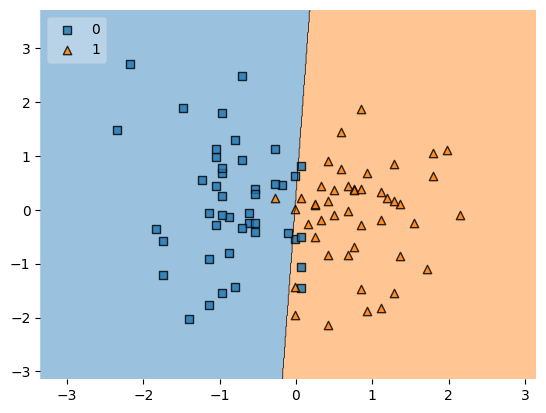

In [ ]:
plot_decision_regions(X_train,y_train.values,clf=clf,legend=2)